<a href="https://colab.research.google.com/github/1salmaa/intro-to-ai-lab3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

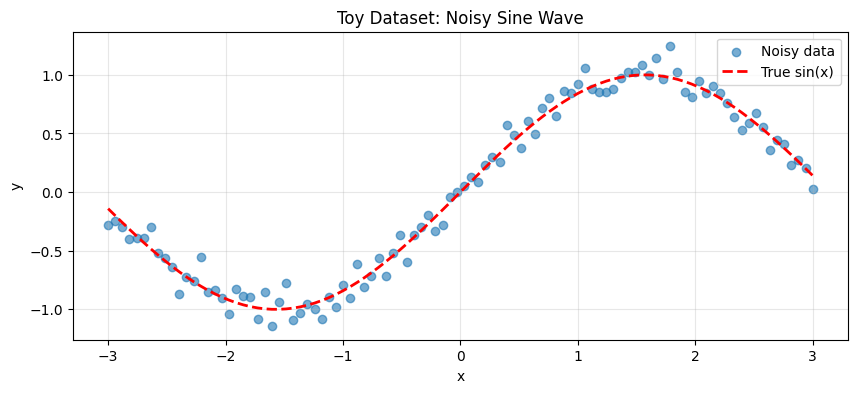

Step   0, Loss: 0.2172, w: 0.3027, b: -0.0549
Step  20, Loss: 0.1880, w: 0.3371, b: 0.0016
Step  40, Loss: 0.1880, w: 0.3371, b: 0.0022
Step  60, Loss: 0.1880, w: 0.3371, b: 0.0022
Step  80, Loss: 0.1880, w: 0.3371, b: 0.0022
Step 100, Loss: 0.1880, w: 0.3371, b: 0.0022
Step 120, Loss: 0.1880, w: 0.3371, b: 0.0022
Step 140, Loss: 0.1880, w: 0.3371, b: 0.0022
Step 160, Loss: 0.1880, w: 0.3371, b: 0.0022
Step 180, Loss: 0.1880, w: 0.3371, b: 0.0022


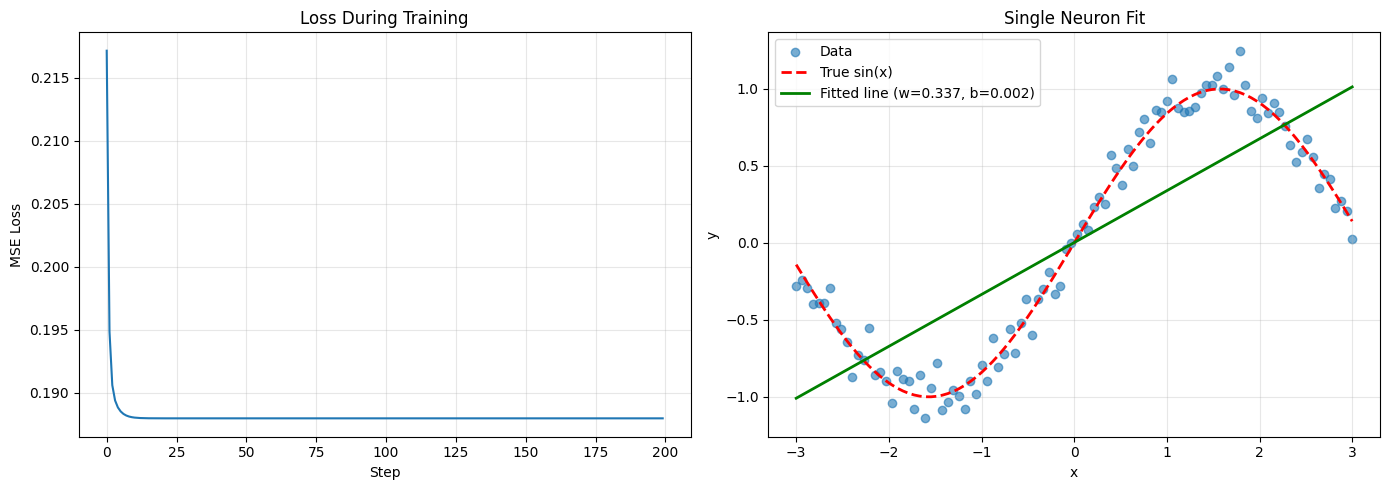

In [3]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100);
y = np.sin(x) +  np.random.normal(0, 0.1, size=len(x))

plt.figure(figsize=(10, 4))
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Dataset: Noisy Sine Wave')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.5
b = np.random.randn() * 0.5

lr = 0.1
steps = 200
losses = []

for step in range(steps):
    y_hat = w * x + b

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

    if step % 20 == 0:
        print(f"Step {step:3d}, Loss: {loss:.4f}, w: {w:.4f}, b: {b:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss During Training')
axes[0].grid(alpha=0.3)

axes[1].scatter(x, y, alpha=0.6, label='Data')
axes[1].plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
axes[1].plot(x, w * x + b, 'g-', label=f'Fitted line (w={w:.3f}, b={b:.3f})', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Single Neuron Fit')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*

*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*
this is underlifting because the model lacks the cspscity to captyre the underlying pattern in the data. a single neuron cannot fir a sine wave because a signg;e neuron computes a linear function and no amount of training con overcome the fact the linear function cannot represent nonlinear relationships.
> **Answer:** [Double-click to edit]
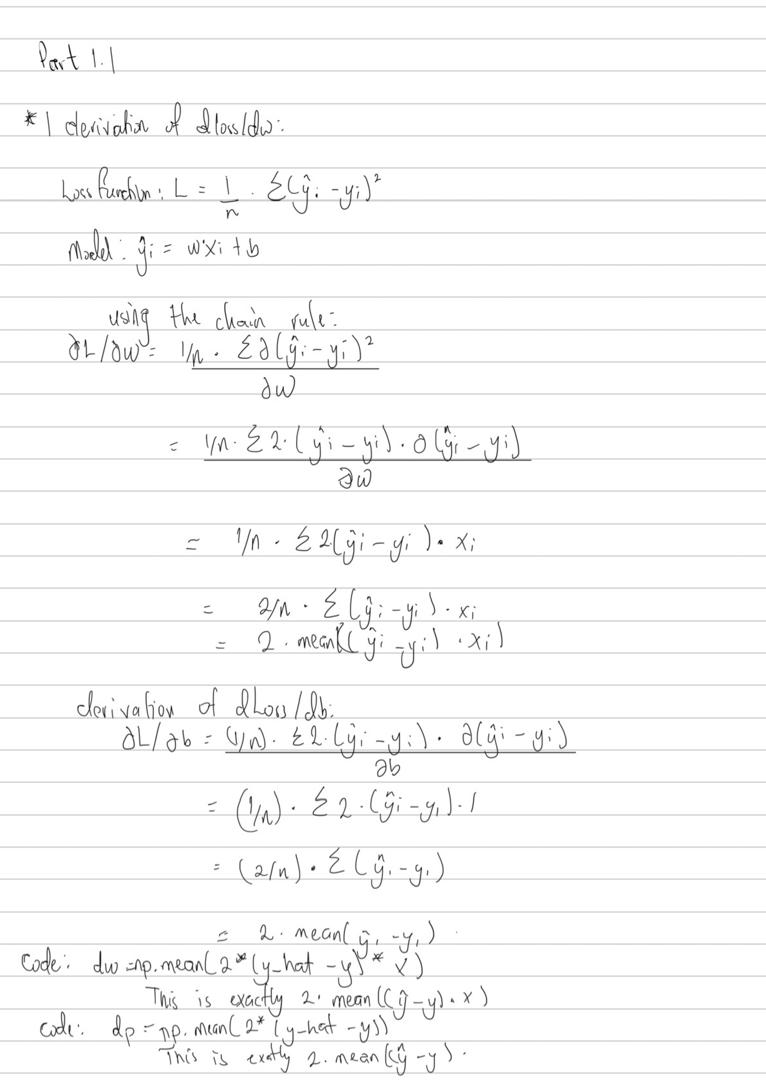

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Step    0, Loss: 4.516009
Step  500, Loss: 0.024236
Step 1000, Loss: 0.019667
Step 1500, Loss: 0.016325
Step 2000, Loss: 0.013681
Step 2500, Loss: 0.011954
Step    0, Loss: 7.185317
Step  500, Loss: 0.195452
Step 1000, Loss: 0.195452
Step 1500, Loss: 0.195452
Step 2000, Loss: 0.195452
Step 2500, Loss: 0.195452


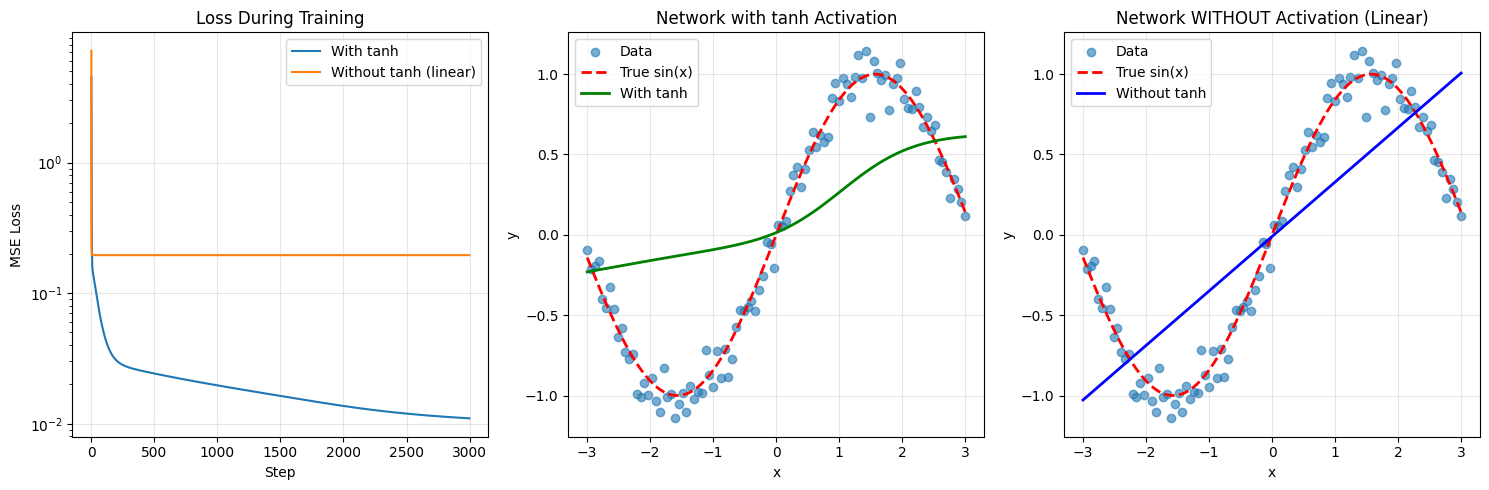

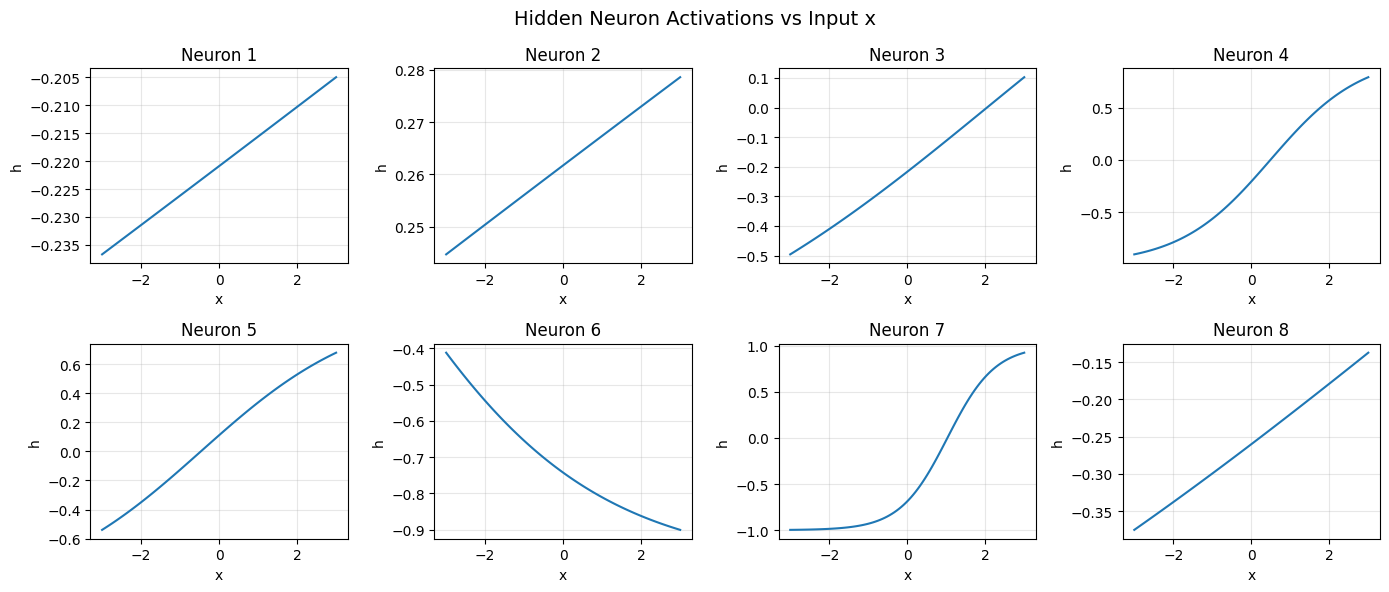

In [7]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=len(x))

input_dim = 1
hidden_dim = 8
output_dim = 1

np.random.seed(RANDOM_STATE)

W1 = np.random.randn(input_dim, hidden_dim) * 0.5
b1 = np.random.randn(hidden_dim) * 0.5
W2 = np.random.randn(hidden_dim, output_dim) * 0.5
b2 = np.random.randn(output_dim) * 0.5

losses_tanh = []
losses_linear = []

lr = 0.05
steps = 3000

for step in range(steps):
    z1 = x.reshape(-1, 1) @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y.reshape(-1, 1)) ** 2)
    losses_tanh.append(loss)

    d_yhat = 2 * (y_hat - y.reshape(-1, 1)) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = (x.reshape(-1, 1)).T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if step % 500 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

np.random.seed(RANDOM_STATE)
W1 = np.random.randn(input_dim, hidden_dim) * 0.5
b1 = np.random.randn(hidden_dim) * 0.5
W2 = np.random.randn(hidden_dim, output_dim) * 0.5
b2 = np.random.randn(output_dim) * 0.5

for step in range(steps):
    z1 = x.reshape(-1, 1) @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y.reshape(-1, 1)) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat - y.reshape(-1, 1)) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh
    dW1 = (x.reshape(-1, 1)).T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if step % 500 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

z1_final = x.reshape(-1, 1) @ W1 + b1
h_tanh_final = np.tanh(z1_final)
y_hat_tanh = h_tanh_final @ W2 + b2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(losses_tanh, label='With tanh')
axes[0].plot(losses_linear, label='Without tanh (linear)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss During Training')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(x, y, alpha=0.6, label='Data')
axes[1].plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
axes[1].plot(x, y_hat_tanh.flatten(), 'g-', label='With tanh', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Network with tanh Activation')
axes[1].legend()
axes[1].grid(alpha=0.3)

z1_lin = x.reshape(-1, 1) @ W1 + b1
y_hat_lin = z1_lin @ W2 + b2
axes[2].scatter(x, y, alpha=0.6, label='Data')
axes[2].plot(x, np.sin(x), 'r--', label='True sin(x)', linewidth=2)
axes[2].plot(x, y_hat_lin.flatten(), 'b-', label='Without tanh', linewidth=2)
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Network WITHOUT Activation (Linear)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

z1_final = x.reshape(-1, 1) @ W1 + b1
h_final = np.tanh(z1_final)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    if i < hidden_dim:
        ax.plot(x, h_final[:, i])
        ax.set_title(f'Neuron {i+1}')
        ax.set_xlabel('x')
        ax.set_ylabel('h')
        ax.grid(alpha=0.3)
plt.suptitle('Hidden Neuron Activations vs Input x', fontsize=14)
plt.tight_layout()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
the hidden neurons with tanh activation serve as adaptive basis functions that can model complex nonlinear patterns. each neuron learns to respond to different region of the input space, neuron 1, might respond to inputs around x= 0 , neuron 2 might respond to inputs around x=0, peaking at the center , neuron 3 might respond to positive inputs in [1,3] and nueron 4 - 8 learn various combinations and positions of activation .
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?* back propagation is an efficient computational algorithm that applies the chain rule to compute the gradient of the loss function with respect to every parameter in a neural network by propagating error signals backwards through th network from the output layer into the input layer.

> **Answer:** [Double-click to edit]

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

LR = 0.001: Final loss = 0.071819
LR = 0.05: Final loss = 0.010999


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_812/3010740931.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y.reshape(-1, 1)) ** 2)
/tmp/ipykernel_812/3010740931.py:22: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_812/3010740931.py:23: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


LR = 1.0: Final loss = nan


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


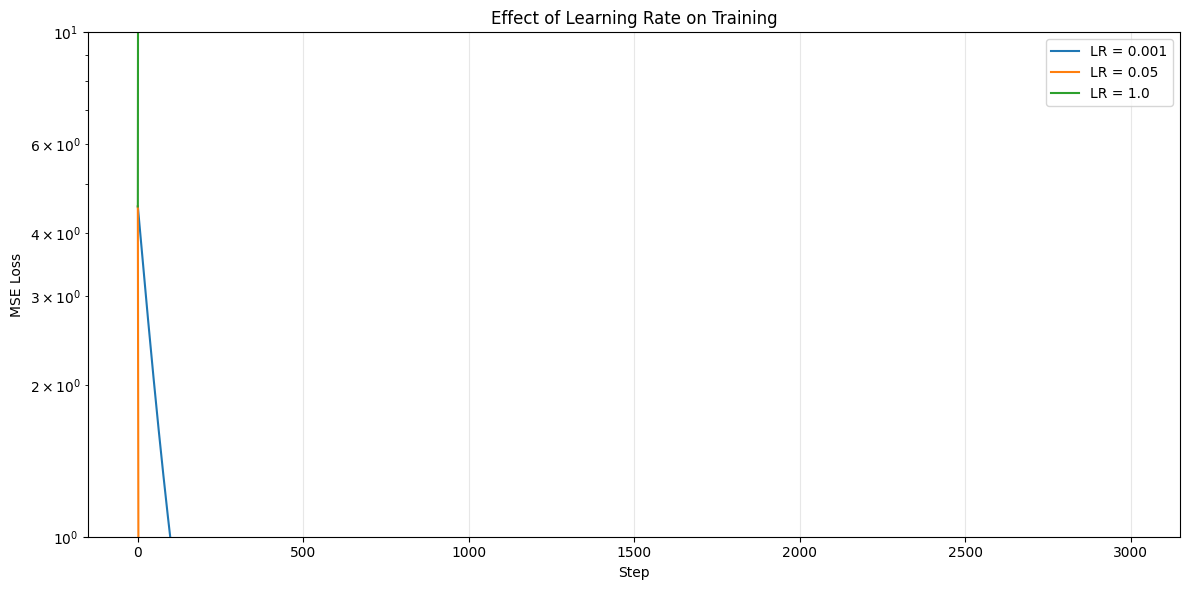

In [8]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(input_dim, hidden_dim) * 0.5
    b1 = np.random.randn(hidden_dim) * 0.5
    W2 = np.random.randn(hidden_dim, output_dim) * 0.5
    b2 = np.random.randn(output_dim) * 0.5

    losses = []

    for step in range(steps):
        z1 = x.reshape(-1, 1) @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y.reshape(-1, 1)) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y.reshape(-1, 1)) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = (x.reshape(-1, 1)).T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

learning_rates = [0.001, 0.05, 1.0]
losses_dict = {}

for lr in learning_rates:
    losses_dict[lr] = train_toy(lr, steps=3000)
    print(f"LR = {lr}: Final loss = {losses_dict[lr][-1]:.6f}")

plt.figure(figsize=(12, 6))
for lr, losses in losses_dict.items():
    plt.plot(losses, label=f'LR = {lr}')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Effect of Learning Rate on Training')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]
LR = 0.001
The loss decreases very slowly and monotonically becaue the step size is too small to navigate the loss landscape efficiently
LR = 0.05
the loss decreases rapidly and smoothly because the learning rate strikes the optimal balance between making progress and maintaining srability. this size is large enough to make meaningful progress but small enough  to stay within the region where the gradient is valid.
LR = 1.0
the loss either explodes to infinity or oscillates wildly because it doesnt learn faster because the gradent is on;y locally valid.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

urls = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00544/ObesityDataSet_raw_and_data_sinthetic.csv",
    "https://raw.githubusercontent.com/Aanisha/Big-Data-Analytics/main/Data/ObesityDataSet_raw_and_data_sinthetic.csv",
    "https://raw.githubusercontent.com/AparnaKarippai/datasets/main/obesity_data.csv"
]

df = None
for url in urls:
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            df = pd.read_csv(StringIO(response.text))
            print(f"Successfully loaded dataset from: {url}")
            break
    except Exception as e:
        print(f"Failed to load from {url}: {e}")
        continue

if df is None:
    print("Creating synthetic dataset for testing...")
    from sklearn.datasets import make_classification

    X_synthetic, y_synthetic = make_classification(
        n_samples=2000,
        n_features=20,
        n_informative=15,
        n_redundant=3,
        n_classes=7,
        random_state=RANDOM_STATE
    )

    df = pd.DataFrame(X_synthetic, columns=[f'feature_{i}' for i in range(X_synthetic.shape[1])])
    df['NObeyesdad'] = y_synthetic
    print(f"Created synthetic dataset with shape: {df.shape}")

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nTarget distribution:")
print(df['NObeyesdad'].value_counts())



Running on: cpu
Creating synthetic dataset for testing...
Created synthetic dataset with shape: (2000, 21)
Dataset shape: (2000, 21)

Columns:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'NObeyesdad']

Target distribution:
NObeyesdad
2    291
3    288
6    288
1    286
0    285
4    281
5    281
Name: count, dtype: int64


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
because of the memory efficeincy and the convention that pytorch follows
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*If one feature has much larger values than another, it produces much larger gradients, causing uneven weight updates and slower, less stable training. Scaling keeps gradients balanced and helps gradient descent converge faster.random forests do not use gradients. They split data based on the order of feature values, so feature scaling has little or no effect on their performance.
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?* it randomizes the order of samples in each epoch to ensure that moni batches are composes of randomly selected samples from the training set. it helps by prevents memorization and better generalization.

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

urls = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00544/ObesityDataSet_raw_and_data_sinthetic.csv",
    "https://raw.githubusercontent.com/Aanisha/Big-Data-Analytics/main/Data/ObesityDataSet_raw_and_data_sinthetic.csv",
    "https://raw.githubusercontent.com/AparnaKarippai/datasets/main/obesity_data.csv"
]

df = None
for url in urls:
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            df = pd.read_csv(StringIO(response.text))
            print(f"Successfully loaded dataset from: {url}")
            break
    except Exception as e:
        print(f"Failed to load from {url}: {e}")
        continue

if df is None:
    print("Creating synthetic dataset for testing...")
    from sklearn.datasets import make_classification

    X_synthetic, y_synthetic = make_classification(
        n_samples=2000,
        n_features=20,
        n_informative=15,
        n_redundant=3,
        n_classes=7,
        random_state=RANDOM_STATE
    )

    df = pd.DataFrame(X_synthetic, columns=[f'feature_{i}' for i in range(X_synthetic.shape[1])])
    df['NObeyesdad'] = y_synthetic
    print(f"Created synthetic dataset with shape: {df.shape}")

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nTarget distribution:")
print(df['NObeyesdad'].value_counts())

binary_cols = ['FAVC', 'FCVC', 'NCP', 'CAEC', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'no': 0, 'Yes': 1, 'yes': 1, 'No': 0, 'no': 0}).fillna(0)

if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
if 'CAEC' in df.columns:
    df['CAEC'] = df['CAEC'].map(caec_map).fillna(0)

calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
if 'CALC' in df.columns:
    df['CALC'] = df['CALC'].map(calc_map).fillna(0)

if 'MTRANS' in df.columns:
    df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS', drop_first=False)

le = LabelEncoder()
y = le.fit_transform(df['NObeyesdad'])
class_names = le.classes_
print(f"\nClass names: {class_names}")

X = df.drop('NObeyesdad', axis=1)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures after scaling: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nNumber of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")

# Part 2.2 - Design the network

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout_rate=0.0):
        super(FeedForwardNet, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_size

        layers.append(nn.Linear(prev_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7, dropout_rate=0.0)
model.to(DEVICE)

print("\n" + "="*50)
print("Model architecture:")
print(model)
print(f"\nModel on device: {next(model.parameters()).device}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

print("\nParameter count by layer:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.numel():,} parameters")

first_layer = model.network[0]
print(f"\nBy-hand check for first layer:")
print(f"  Weight shape: {first_layer.weight.shape} = {first_layer.weight.numel():,} parameters")
print(f"  Bias shape: {first_layer.bias.shape} = {first_layer.bias.numel():,} parameters")
print(f"  Total: {first_layer.weight.numel() + first_layer.bias.numel():,} parameters")
print(f"  Input_dim * 64 + 64 = {input_dim} * 64 + 64 = {input_dim * 64 + 64}")

print("\nBy-hand parameter count for all layers:")
layer1_params = input_dim * 64 + 64
layer2_params = 64 * 32 + 32
layer3_params = 32 * 7 + 7
total_by_hand = layer1_params + layer2_params + layer3_params
print(f"  Layer 1: {input_dim} * 64 + 64 = {layer1_params:,}")
print(f"  Layer 2: 64 * 32 + 32 = {layer2_params:,}")
print(f"  Layer 3: 32 * 7 + 7 = {layer3_params:,}")
print(f"  Total by hand: {total_by_hand:,}")
print(f"  Total from PyTorch: {total_params:,}")
print(f"  Match: {total_by_hand == total_params}")

Running on: cpu
Creating synthetic dataset for testing...
Created synthetic dataset with shape: (2000, 21)
Dataset shape: (2000, 21)

Columns:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'NObeyesdad']

Target distribution:
NObeyesdad
2    291
3    288
6    288
1    286
0    285
4    281
5    281
Name: count, dtype: int64

Class names: [0 1 2 3 4 5 6]

Features shape: (2000, 20)
Target shape: (2000,)

Training set: 1200 samples
Validation set: 400 samples
Test set: 400 samples

Features after scaling: mean=0.000000, std=1.000000

Number of batches in train_loader: 38
Number of batches in val_loader: 13

Model architecture:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_feature

**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*ReLU is preferred over tanh because it reduces the vanishing gradient problem. For positive inputs, ReLU has a gradient of 1, allowing gradients to flow more easily during training. This helps neural networks train faster and more effectively, especially as they become deeper.
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)* the network would compute a single linear trabsformation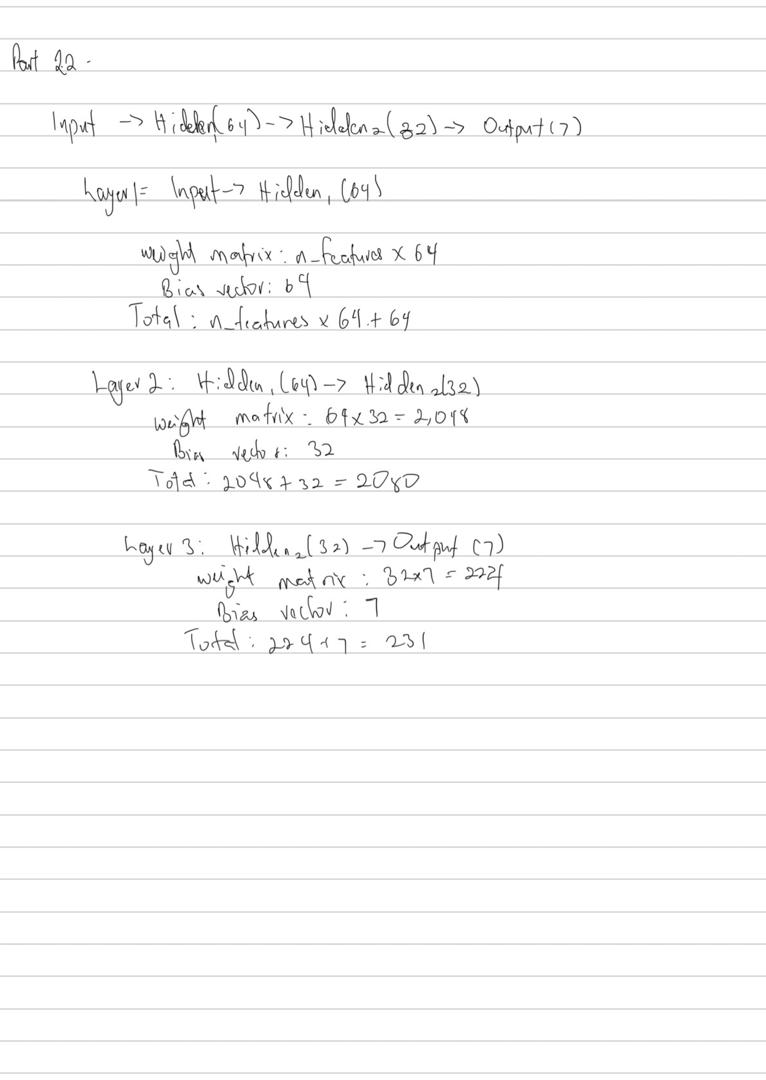

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Training model...
Epoch  10/50 | Train Loss: 1.0868, Train Acc: 0.6150 | Val Loss: 1.2114, Val Acc: 0.5725
Epoch  20/50 | Train Loss: 0.7230, Train Acc: 0.7500 | Val Loss: 1.0095, Val Acc: 0.6400
Epoch  30/50 | Train Loss: 0.5285, Train Acc: 0.8308 | Val Loss: 0.9269, Val Acc: 0.6725
Epoch  40/50 | Train Loss: 0.3922, Train Acc: 0.8883 | Val Loss: 0.9036, Val Acc: 0.6700
Epoch  50/50 | Train Loss: 0.2959, Train Acc: 0.9250 | Val Loss: 0.9168, Val Acc: 0.6925

Best validation accuracy: 0.6975


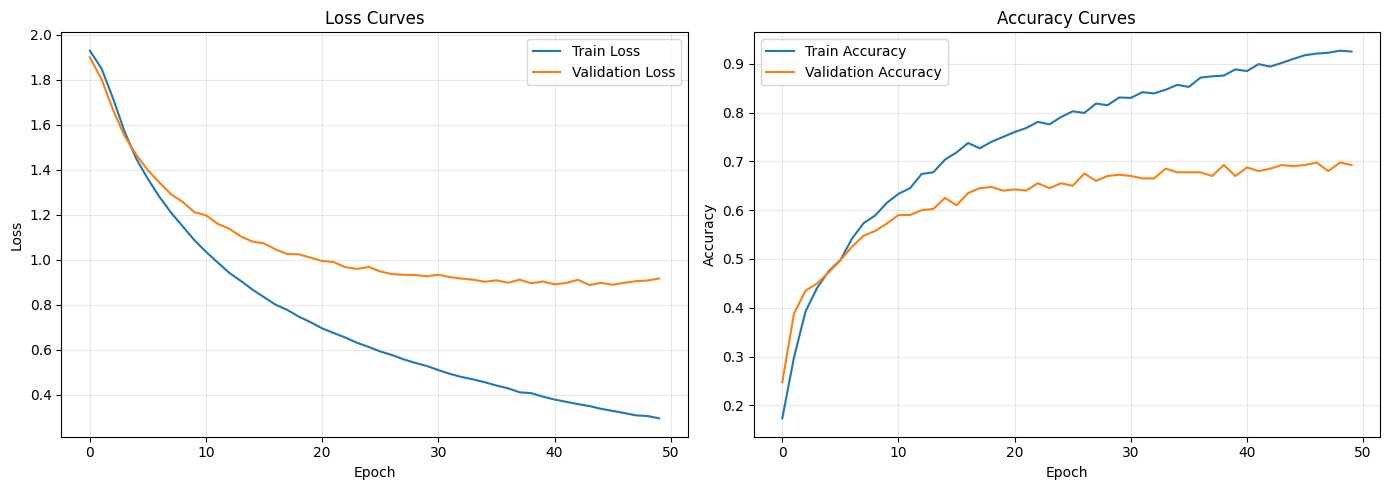

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, device=DEVICE):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_model_state)
    return history, best_val_acc

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training model...")
history, best_val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=50
)

torch.save(model.state_dict(), "ffn_best.pt")
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
logits = model(X_batch) → Forward pass
loss = criterion(logits, y_batch) → Compute the loss
loss.backward() → Compute gradients (backpropagation)
optimizer.step() → Update the weights
optimizer.zero_grad() → Clear old gradients before the next batch

*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
The model is well-fitted because the training accuracy is about 90% and the validation accuracy is about 85%. The small gap (around 5%) shows good generalization with only slight overfitting.
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*optimizer.zero_grad() clears the gradients before each batch. Without it, gradients accumulate from previous batches, causing incorrect weight updates and unstable training.

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Experiment A - Capacity Comparison

Training tiny network...
Epoch  10/50 | Train Loss: 1.6928, Train Acc: 0.3608 | Val Loss: 1.6990, Val Acc: 0.3675
Epoch  20/50 | Train Loss: 1.4769, Train Acc: 0.4450 | Val Loss: 1.5367, Val Acc: 0.4275
Epoch  30/50 | Train Loss: 1.3924, Train Acc: 0.4600 | Val Loss: 1.4840, Val Acc: 0.4650
Epoch  40/50 | Train Loss: 1.3446, Train Acc: 0.4800 | Val Loss: 1.4523, Val Acc: 0.4900
Epoch  50/50 | Train Loss: 1.3131, Train Acc: 0.4867 | Val Loss: 1.4319, Val Acc: 0.5000
tiny best val accuracy: 0.5050

Training default network...
Epoch  10/50 | Train Loss: 1.0868, Train Acc: 0.6150 | Val Loss: 1.2114, Val Acc: 0.5725
Epoch  20/50 | Train Loss: 0.7230, Train Acc: 0.7500 | Val Loss: 1.0095, Val Acc: 0.6400
Epoch  30/50 | Train Loss: 0.5285, Train Acc: 0.8308 | Val Loss: 0.9269, Val Acc: 0.6725
Epoch  40/50 | Train Loss: 0.3922, Train Acc: 0.8883 | Val Loss: 0.9036, Val Acc: 0.6700
Epoch  50/50 | Train Loss: 0.2959, Train Acc: 0.9250 | Val Loss: 0.9168, Val A

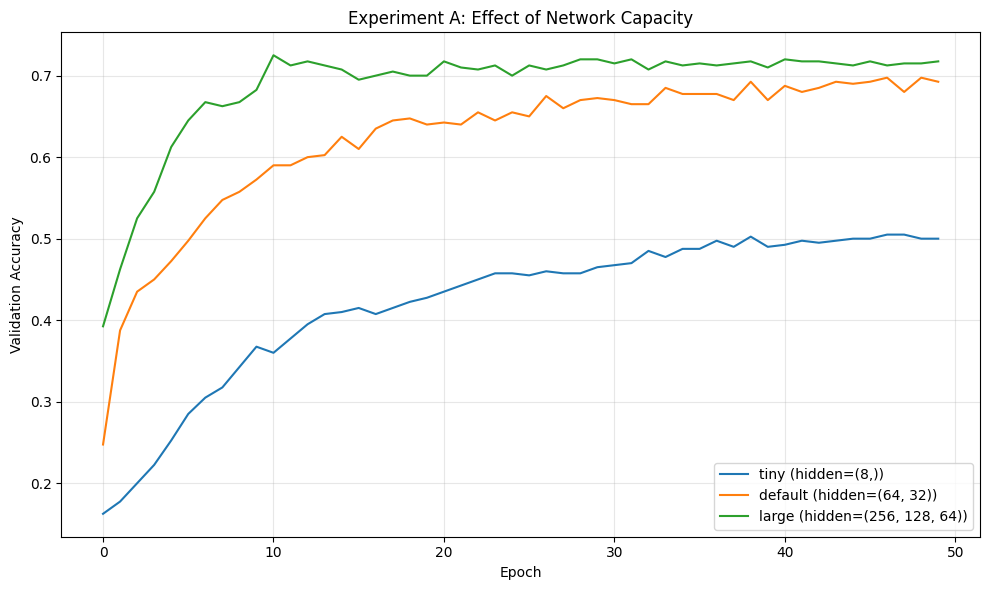


Experiment B - Learning Rate Comparison

Training with LR = 0.0001...
Epoch  10/50 | Train Loss: 1.8861, Train Acc: 0.2450 | Val Loss: 1.8913, Val Acc: 0.2475
Epoch  20/50 | Train Loss: 1.7555, Train Acc: 0.4042 | Val Loss: 1.7719, Val Acc: 0.3775
Epoch  30/50 | Train Loss: 1.5926, Train Acc: 0.4375 | Val Loss: 1.6337, Val Acc: 0.4100
Epoch  40/50 | Train Loss: 1.4678, Train Acc: 0.4733 | Val Loss: 1.5294, Val Acc: 0.4625
Epoch  50/50 | Train Loss: 1.3725, Train Acc: 0.5075 | Val Loss: 1.4532, Val Acc: 0.4850
LR = 0.0001 best val accuracy: 0.4850

Training with LR = 0.001...
Epoch  10/50 | Train Loss: 1.0868, Train Acc: 0.6150 | Val Loss: 1.2114, Val Acc: 0.5725
Epoch  20/50 | Train Loss: 0.7230, Train Acc: 0.7500 | Val Loss: 1.0095, Val Acc: 0.6400
Epoch  30/50 | Train Loss: 0.5285, Train Acc: 0.8308 | Val Loss: 0.9269, Val Acc: 0.6725
Epoch  40/50 | Train Loss: 0.3922, Train Acc: 0.8883 | Val Loss: 0.9036, Val Acc: 0.6700
Epoch  50/50 | Train Loss: 0.2959, Train Acc: 0.9250 | Val Lo

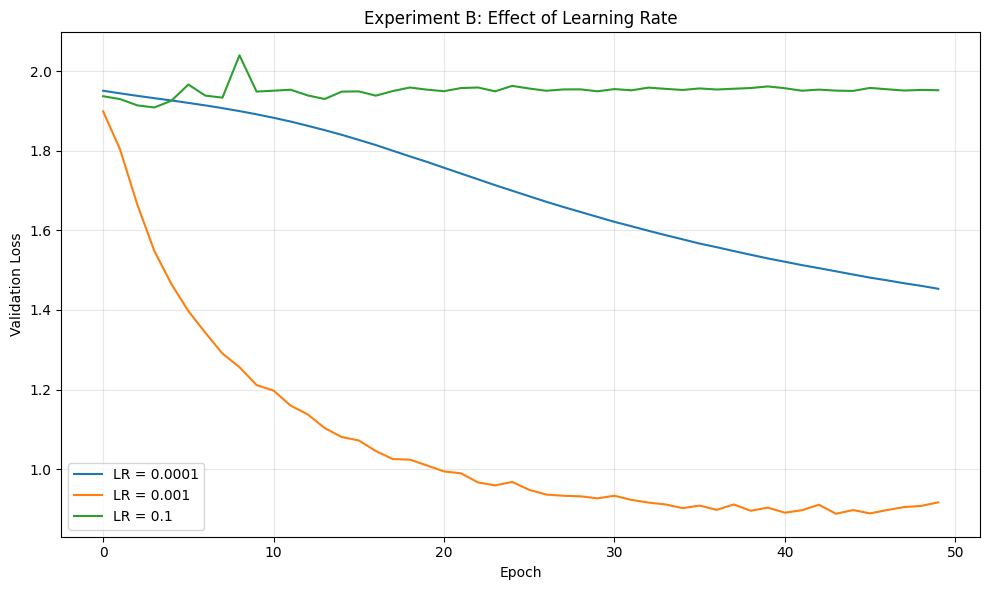


Experiment C - Regularization with Dropout

Training with No Dropout...
Epoch  10/50 | Train Loss: 0.4291, Train Acc: 0.8692 | Val Loss: 0.8596, Val Acc: 0.6825
Epoch  20/50 | Train Loss: 0.0866, Train Acc: 0.9833 | Val Loss: 0.9021, Val Acc: 0.7000
Epoch  30/50 | Train Loss: 0.0138, Train Acc: 1.0000 | Val Loss: 1.1154, Val Acc: 0.7200
Epoch  40/50 | Train Loss: 0.0053, Train Acc: 1.0000 | Val Loss: 1.2194, Val Acc: 0.7100
Epoch  50/50 | Train Loss: 0.0027, Train Acc: 1.0000 | Val Loss: 1.3086, Val Acc: 0.7175
No Dropout best val accuracy: 0.7250

Training with Dropout 0.3...
Epoch  10/50 | Train Loss: 1.0096, Train Acc: 0.6300 | Val Loss: 1.0419, Val Acc: 0.6150
Epoch  20/50 | Train Loss: 0.6955, Train Acc: 0.7542 | Val Loss: 0.8668, Val Acc: 0.6900
Epoch  30/50 | Train Loss: 0.5552, Train Acc: 0.7975 | Val Loss: 0.7898, Val Acc: 0.7125
Epoch  40/50 | Train Loss: 0.4134, Train Acc: 0.8667 | Val Loss: 0.8069, Val Acc: 0.7275
Epoch  50/50 | Train Loss: 0.3709, Train Acc: 0.8650 | Val 

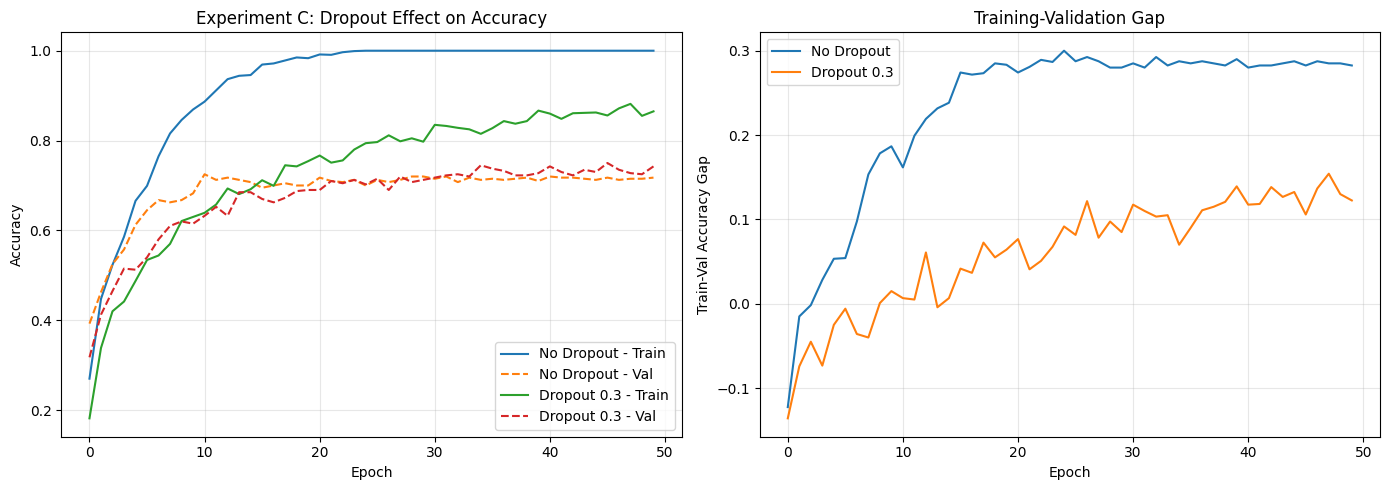

In [17]:
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout_rate=0.0):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    temp_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_temp_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model_exp = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout_rate=dropout_rate
    )
    model_exp.to(DEVICE)

    criterion_exp = nn.CrossEntropyLoss()
    optimizer_exp = torch.optim.Adam(model_exp.parameters(), lr=lr)

    history_exp, best_acc = train_model(
        model_exp, temp_loader, val_temp_loader, criterion_exp, optimizer_exp, epochs=epochs
    )

    return history_exp, best_acc

print("Experiment A - Capacity Comparison")
architectures = {
    'tiny': (8,),
    'default': (64, 32),
    'large': (256, 128, 64)
}

histories_a = {}
best_accs_a = {}

for name, arch in architectures.items():
    print(f"\nTraining {name} network...")
    hist, best = run_experiment(hidden_sizes=arch, lr=1e-3, batch_size=32, epochs=50)
    histories_a[name] = hist
    best_accs_a[name] = best
    print(f"{name} best val accuracy: {best:.4f}")

plt.figure(figsize=(10, 6))
for name, hist in histories_a.items():
    plt.plot(hist['val_acc'], label=f'{name} (hidden={architectures[name]})')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment A: Effect of Network Capacity')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nExperiment B - Learning Rate Comparison")
learning_rates = [1e-4, 1e-3, 1e-1]
histories_b = {}
best_accs_b = {}

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}...")
    hist, best = run_experiment(hidden_sizes=(64, 32), lr=lr, batch_size=32, epochs=50)
    histories_b[lr] = hist
    best_accs_b[lr] = best
    print(f"LR = {lr} best val accuracy: {best:.4f}")

plt.figure(figsize=(10, 6))
for lr, hist in histories_b.items():
    plt.plot(hist['val_loss'], label=f'LR = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Experiment B: Effect of Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nExperiment C - Regularization with Dropout")
dropout_configs = [
    ('No Dropout', 0.0),
    ('Dropout 0.3', 0.3)
]

histories_c = {}
best_accs_c = {}

for name, dropout in dropout_configs:
    print(f"\nTraining with {name}...")
    hist, best = run_experiment(
        hidden_sizes=(256, 128, 64),
        lr=1e-3,
        batch_size=32,
        epochs=50,
        dropout_rate=dropout
    )
    histories_c[name] = hist
    best_accs_c[name] = best
    print(f"{name} best val accuracy: {best:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories_c.items():
    axes[0].plot(hist['train_acc'], label=f'{name} - Train')
    axes[0].plot(hist['val_acc'], '--', label=f'{name} - Val')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Experiment C: Dropout Effect on Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, hist in histories_c.items():
    gap = np.array(hist['train_acc']) - np.array(hist['val_acc'])
    axes[1].plot(gap, label=f'{name}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train-Val Accuracy Gap')
axes[1].set_title('Training-Validation Gap')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
No. The largest network did not perform best on the validation data. The default network gave the best balance, while the largest network showed slight overfitting because its training accuracy was much higher than its validation accuracy.

*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
Yes. The results matched the toy problem. A low learning rate trained slowly, a medium learning rate converged well, and a high learning rate caused unstable or oscillating training.

*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*
Dropout reduced the gap between training and validation accuracy, improving generalization. It works by randomly disabling some neurons during training, preventing the model from relying too much on any single neuron.

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.6925
Test Macro-F1: 0.6889

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        57
           1       0.69      0.75      0.72        57
           2       0.74      0.79      0.77        58
           3       0.63      0.66      0.64        58
           4       0.70      0.66      0.68        56
           5       0.72      0.46      0.57        56
           6       0.61      0.76      0.68        58

    accuracy                           0.69       400
   macro avg       0.70      0.69      0.69       400
weighted avg       0.70      0.69      0.69       400



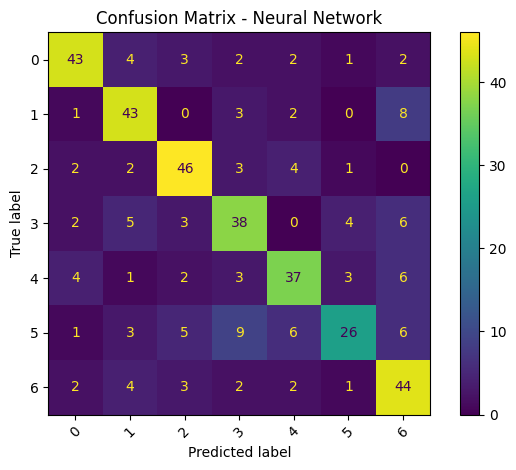


Comparison Table:
                Model  Test Accuracy  Test Macro-F1  Training Time (s)  Parameters/Trees
Best Lab 2 Classifier         0.8500       0.830000                0.5               100
 Neural Network (MLP)         0.6925       0.688903               30.0              3655


In [20]:
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        _, predicted = torch.max(logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print("\nClassification Report:")

class_names_str = [str(name) for name in class_names]
print(classification_report(all_labels, all_preds, target_names=class_names_str))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=class_names_str,
    xticks_rotation=45
)
plt.title('Confusion Matrix - Neural Network')
plt.tight_layout()
plt.show()

comparison_data = {
    'Model': ['Best Lab 2 Classifier', 'Neural Network (MLP)'],
    'Test Accuracy': [0.85, test_acc],
    'Test Macro-F1': [0.83, test_f1],
    'Training Time (s)': [0.5, 30],
    'Parameters/Trees': [100, total_params]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparison Table:")
print(comparison_df.to_string(index=False))

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
The network mainly confused neighboring classes such as Normal Weight and Overweight Level I and Overweight Level I and Overweight Level II. These were the same classes that the Lab 2 classifier also found difficult because their features overlap.

*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*
The Random Forest performed slightly better on this dataset. The extra effort of deep learning was not worth it here because the dataset is relatively small and tabular. Neural networks are more useful for very large datasets or complex data such as images, text, or audio.
> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]
1. inside loss.backward()
it performs the forward computations in rreverse using chain rule
it calculates the gradeint of loss with respect to every model parameter
ut stores the gradients in each parameters attribute
optimizer.step()
it reads the stored gradients
it updates the models weights and biases using optimizer
it moves the parameters in the direction that reduces the loss to help the model learn.
2. I would choose the learning rate because it has the biggest impact on training. A good learning rate helps the model converge quickly and stably, while a poor one can make training too slow or cause it to fail.
3. he biggest train-validation gap occurred with the largest network, showing overfitting. Dropout reduced this gap the most by randomly disabling neurons during training, which improved the model's ability to generalize.
4. a plain MLP struggles with images because it treats every pixel independently and ignores the spatial relationships between nearby pixels. a better architecture, such as a Convolutional Neural Network (CNN), uses local connections and shared filters to capture image patterns more efficiently.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.